# 📚 TP Deep Learning LSTM - Structure complète

Ce TP suit la même structure que le TP Machine Learning, mais en version **Deep Learning** avec un modèle LSTM pour prédire le cours du Bitcoin.

---
# Partie 1 — Chargement du dataset

### Étape 1.1 — Charger le fichier CSV

In [222]:
import pandas as pd

df = pd.read_csv("../BTC-Daily.csv")

### Étape 1.2 — Afficher les premières lignes

In [223]:
df.head()

,unix,date,symbol,open,high,low,close,Volume BTC,Volume USD
0,1646092800,2022-03-01 00:00:00,BTC/USD,43221.71,43626.49,43185.48,43185.48,49.006289,2.116360e+06
1,1646006400,2022-02-28 00:00:00,BTC/USD,37717.10,44256.08,37468.99,43178.98,3160.618070,1.364723e+08
2,1645920000,2022-02-27 00:00:00,BTC/USD,39146.66,39886.92,37015.74,37712.68,1701.817043,6.418008e+07
3,1645833600,2022-02-26 00:00:00,BTC/USD,39242.64,40330.99,38600.00,39146.66,912.724087,3.573010e+07
4,1645747200,2022-02-25 00:00:00,BTC/USD,38360.93,39727.97,38027.61,39231.64,2202.851827,8.642149e+07


### Étape 1.3 — Informations générales

In [224]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2651 entries, 0 to 2650
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   unix        2651 non-null   int64  
 1   date        2651 non-null   str    
 2   symbol      2651 non-null   str    
 3   open        2651 non-null   float64
 4   high        2651 non-null   float64
 5   low         2651 non-null   float64
 6   close       2651 non-null   float64
 7   Volume BTC  2651 non-null   float64
 8   Volume USD  2651 non-null   float64
dtypes: float64(6), int64(1), str(2)
memory usage: 186.5 KB


### Étape 1.4 — Valeurs manquantes

In [225]:
df.isnull().sum()

unix          0
date          0
symbol        0
open          0
high          0
low           0
close         0
Volume BTC    0
Volume USD    0
dtype: int64

---
# Partie 2 — Nettoyage

### Étape 2.1 — Conversion de la date

In [226]:
df["Date"] = pd.to_datetime(df["date"])

### Étape 2.2 — Trier les dates

In [227]:
df = df.sort_values("Date")

### Étape 2.3 — Garder seulement la cible

Pour commencer, on garde uniquement la colonne `Close` (prix de clôture).

In [228]:
x = df.drop(columns=["date", "symbol", "close"])
y = df["close"]

### Étape 2.4 — Visualisation du prix de clôture

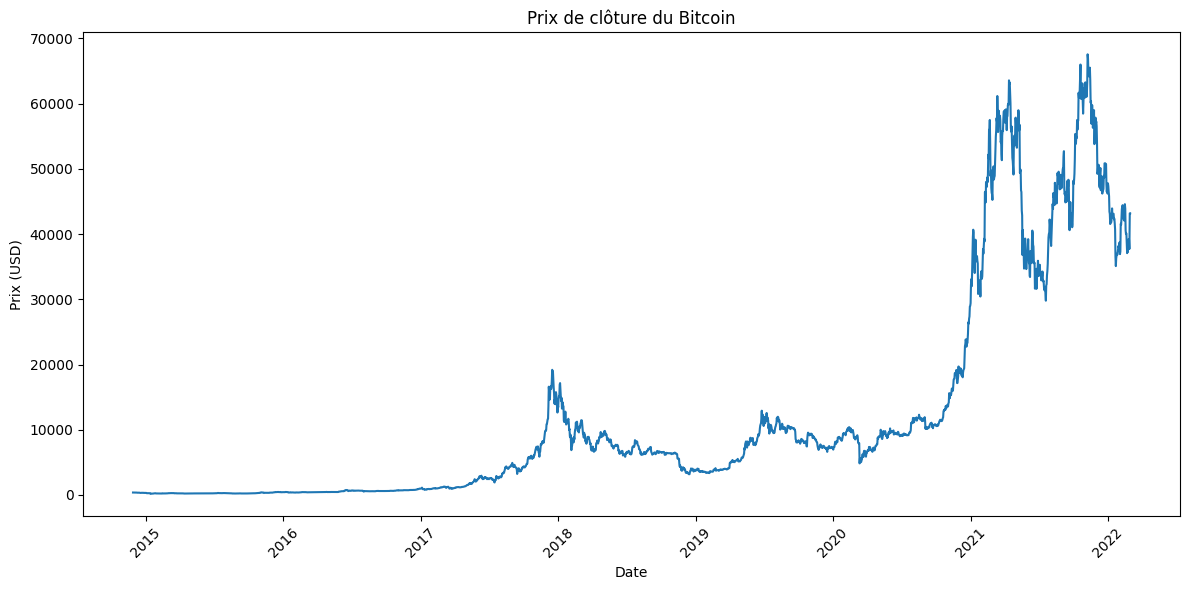

In [229]:
import matplotlib.pyplot as plt

# 2 features :
#   col 0 → close       : cible à prédire
#   col 1 → Volume USD  : activité marché en dollars
data = df[["close", "Volume USD"]]

plt.figure(figsize=(12, 6))
plt.plot(df["Date"], df["close"])
plt.title("Prix de clôture du Bitcoin")
plt.xlabel("Date")
plt.ylabel("Prix (USD)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


---
# Partie 3 — Préparation LSTM

### Étape 3.1 — Normalisation

Le LSTM fonctionne mieux avec des données normalisées entre 0 et 1.

In [230]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

scaled_data = scaler.fit_transform(data)

### Étape 3.2 — Création des séquences

Le LSTM apprend à partir de **séquences** de données :

```
30 jours
 ↓
Jour 31
```

On crée des fenêtres glissantes de `window = 30` jours pour prédire le jour suivant.

In [231]:
import numpy as np

X = []
y = []

window = 30   # 30 jours : plus ciblé, meilleur signal/bruit qu'une fenêtre de 60

for i in range(window, len(scaled_data)):
    X.append(scaled_data[i - window:i, :])   # close + Volume USD
    y.append(scaled_data[i, 0])               # cible = close (colonne 0)

X = np.array(X)   # shape : (samples, 30, 2)
y = np.array(y)


### Étape 3.3 — Reshape pour LSTM

Le LSTM attend des données en 3D : `(samples, timesteps, features)`

In [232]:
# X est déjà en 3D (samples, timesteps, features)
n_features = X.shape[2]   # = 2 (close, Volume USD)
print(f"Forme de X : {X.shape}")   # attendu : (n, 30, 2)
print(f"Nombre de features : {n_features}")


Forme de X : (2621, 30, 2)
Nombre de features : 2


### Étape 3.4 — Train Test Split

On garde 80% pour l'entraînement et 20% pour le test.

In [233]:
split = int(len(X) * 0.8)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

print(f"Train : {X_train.shape}")
print(f"Test  : {X_test.shape}")

Train : (2096, 30, 2)
Test  : (525, 30, 2)


---
# Partie 4 — Construction du modèle

### Étape 4.1 — Imports Keras

In [234]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout


### Étape 4.2 — Architecture du modèle

2 couches LSTM empilées + 1 couche Dense de sortie.

In [258]:
lstm_model = Sequential()

# Couche 1 : 50 neurones
lstm_model.add(LSTM(50, return_sequences=True, input_shape=(30, 2)))

# Couche 2 : 50 neurones
lstm_model.add(LSTM(50))

# Sortie
lstm_model.add(Dense(1))

lstm_model.summary()


c:\Users\paulm\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_24"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_29 (LSTM)                  │ (None, 30, 50)         │        10,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_30 (LSTM)                  │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_46 (Dense)                │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,851 (120.51 KB)

 Trainable params: 30,851 (120.51 KB)

 Non-trainable params: 0 (0.00 B)

### Étape 4.3 — Compilation

Optimiseur `adam` + loss `mse` (Mean Squared Error) pour une régression.

In [259]:
lstm_model.compile(
    optimizer="adam",
    loss="mse"
)

### Étape 4.4 — Entraînement

In [260]:
# Early stopping 
# ReduceLROnPlateau : Réduit le taux d'apprentissage si la validation ne s'améliore pas
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

callbacks = [
    EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3)
]


In [261]:
history = lstm_model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.1,
    callbacks=callbacks
)


Epoch 1/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 4.6747e-04 - val_loss: 2.4133e-04 - learning_rate: 0.0010
Epoch 2/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.0088e-04 - val_loss: 1.4613e-04 - learning_rate: 0.0010
Epoch 3/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 9.0959e-05 - val_loss: 1.0922e-04 - learning_rate: 0.0010
Epoch 4/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 7.8631e-05 - val_loss: 9.7039e-05 - learning_rate: 0.0010
Epoch 5/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 7.0738e-05 - val_loss: 9.0529e-05 - learning_rate: 0.0010
Epoch 6/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 6.4373e-05 - val_loss: 1.2506e-04 - learning_rate: 0.0010
Epoch 7/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 5.5870e-05 - val_loss: 8.2531e-05 - learning_rate: 5.0000e-04
Epoch 8/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 5.4375e-05 - val_loss: 8.5861e-05 - learning_rate: 5.0000e-04
Epoch 9/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - los

Evaluation du modele LSTM 

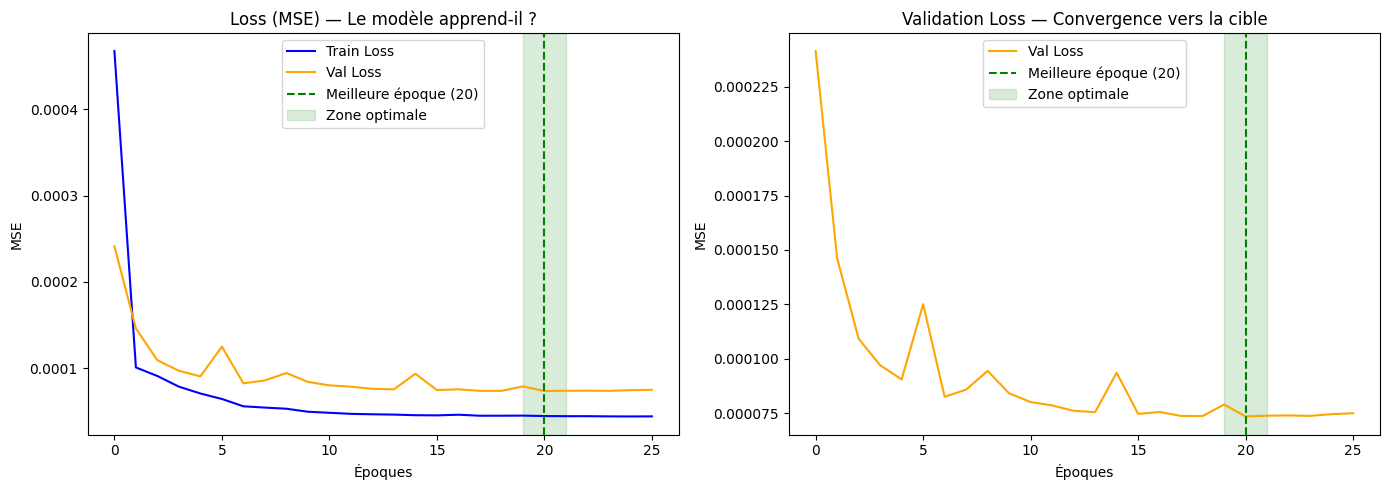

  Époques réalisées        : 26 / 50
  Meilleure époque         : 20
  MSE train (finale)       : 0.000044
  MSE val   (finale)       : 0.000075
  MSE val   (meilleure)    : 0.000074
  MAE et RMSE en $ seront calculés en Partie 5


In [262]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

best_epoch = np.argmin(history.history["val_loss"])
total_epochs = len(history.history["val_loss"])

axes[0].plot(history.history["loss"],     label="Train Loss", color="blue")
axes[0].plot(history.history["val_loss"], label="Val Loss",   color="orange")
axes[0].axvline(x=best_epoch, color="green", linestyle="--", linewidth=1.5, label=f"Meilleure époque ({best_epoch})")
axes[0].axvspan(max(0, best_epoch - 1), min(total_epochs - 1, best_epoch + 1), color="green", alpha=0.15, label="Zone optimale")
axes[0].set_title("Loss (MSE) — Le modèle apprend-il ?")
axes[0].set_xlabel("Époques")
axes[0].set_ylabel("MSE")
axes[0].legend()

axes[1].plot(history.history["val_loss"], label="Val Loss", color="orange")
axes[1].axvline(x=best_epoch, color="green", linestyle="--", linewidth=1.5, label=f"Meilleure époque ({best_epoch})")
axes[1].axvspan(max(0, best_epoch - 1), min(total_epochs - 1, best_epoch + 1), color="green", alpha=0.15, label="Zone optimale")
axes[1].set_title("Validation Loss — Convergence vers la cible")
axes[1].set_xlabel("Époques")
axes[1].set_ylabel("MSE")
axes[1].legend()

fig.tight_layout()
plt.show()

print("=" * 45)
print(f"  Époques réalisées        : {total_epochs} / 50")
print(f"  Meilleure époque         : {best_epoch}")
print(f"  MSE train (finale)       : {history.history['loss'][-1]:.6f}")
print(f"  MSE val   (finale)       : {history.history['val_loss'][-1]:.6f}")
print(f"  MSE val   (meilleure)    : {history.history['val_loss'][best_epoch]:.6f}")
print("=" * 45)
print("  MAE et RMSE en $ seront calculés en Partie 5")


---
# Partie 5 — Évaluation

🎉 Le modèle est entraîné, maintenant on évalue ses performances.

### Prédictions sur le jeu de test

In [263]:
predictions = lstm_model.predict(X_test)

17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


### Inverser la normalisation

On repasse les valeurs à l'échelle originale (en USD).

In [264]:
# Le scaler a été fit sur 2 colonnes → inverse_transform attend 2 colonnes
dummy_pred = np.zeros((len(predictions), 2))
dummy_pred[:, 0] = predictions[:, 0]
predictions = scaler.inverse_transform(dummy_pred)[:, 0].reshape(-1, 1)

dummy_real = np.zeros((len(y_test), 2))
dummy_real[:, 0] = y_test
real_prices = scaler.inverse_transform(dummy_real)[:, 0].reshape(-1, 1)


### Métriques d'évaluation

Calcul du **MAE**, **MSE** et **RMSE**.

In [265]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

lstm_mae  = mean_absolute_error(real_prices, predictions)
lstm_mse  = mean_squared_error(real_prices, predictions)
lstm_rmse = np.sqrt(lstm_mse)

# MAPE — erreur en % (plus facile à interpréter que le MAE en $)
lstm_mape = np.mean(np.abs((real_prices - predictions) / real_prices)) * 100

# Directional Accuracy — est-ce que le modèle prédit la bonne direction (hausse/baisse) ?
real_diff = np.diff(real_prices.flatten())
pred_diff = np.diff(predictions.flatten())
lstm_dir_acc = np.mean((real_diff > 0) == (pred_diff > 0)) * 100

print("=" * 45)
print(f"  MAE              : {lstm_mae:>10,.0f} $")
print(f"  MSE              : {lstm_mse:>10,.0f}")
print(f"  RMSE             : {lstm_rmse:>10,.0f} $")
print(f"  MAPE             : {lstm_mape:>9.2f} %   ← % d'erreur moyen")
print(f"  Directional Acc  : {lstm_dir_acc:>9.2f} %   ← 50% = aléatoire, 60%+ = bien")
print("=" * 45)


  MAE              :      7,595 $
  MSE              : 79,851,416
  RMSE             :      8,936 $
  MAPE             :     16.48 %   ← % d'erreur moyen
  Directional Acc  :     50.76 %   ← 50% = aléatoire, 60%+ = bien


---
# Partie 6 — Visualisation

Comparaison visuelle entre les prix **réels** et les prix **prédits**.

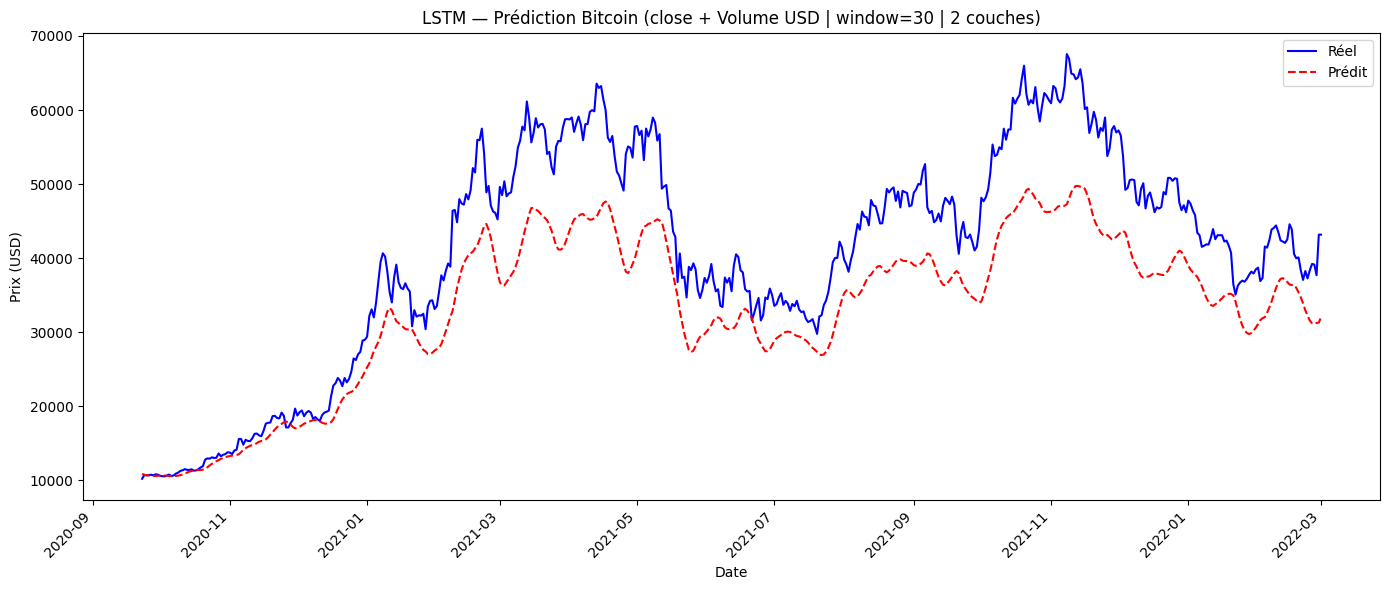


MAE   : 7,595 $  (16.5% d'erreur relative)
RMSE  : 8,936 $
Dir.  : 50.8% de bonnes directions prédites


In [267]:
test_dates = df["Date"].iloc[split + window : split + window + len(y_test)].reset_index(drop=True)

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(test_dates, real_prices, label="Réel",   color="blue",  linewidth=1.5)
ax.plot(test_dates, predictions, label="Prédit", color="red",   linestyle="--", linewidth=1.5)

ax.set_title("LSTM — Prédiction Bitcoin (close + Volume USD | window=30 | 2 couches)")
ax.set_xlabel("Date")
ax.set_ylabel("Prix (USD)")
ax.legend()
fig.autofmt_xdate(rotation=45)
fig.tight_layout()
plt.show()

print(f"\nMAE   : {lstm_mae:,.0f} $  ({lstm_mape:.1f}% d'erreur relative)")
print(f"RMSE  : {lstm_rmse:,.0f} $")
print(f"Dir.  : {lstm_dir_acc:.1f}% de bonnes directions prédites")


---
### Bonus 3 — LSTM Classification (prédiction de direction)

> **Pourquoi 51% de Directional Accuracy avec la régression ?**
>
> Le LSTM de régression (loss = MSE) apprend à prédire un **prix proche du dernier prix connu**.
> La direction (hausse/baisse) est donc quasi-aléatoire — limite fondamentale de l'approche régression.
>
> **Solution** : reformuler en **classification binaire** :
> - `1` → prix de demain > prix d'aujourd'hui (hausse)
> - `0` → prix de demain ≤ prix d'aujourd'hui (baisse)
>
> On optimise directement la **Directional Accuracy** avec `binary_crossentropy`.


In [268]:
from tensorflow.keras.layers import LSTM as LSTMLayer
from tensorflow.keras.callbacks import EarlyStopping

# Créer les labels de direction : 1 si close[t+1] > close[t], sinon 0
close_prices = scaled_data[:, 0]
y_dir = (close_prices[window:] > close_prices[window - 1:-1]).astype(int)

# Même X que pour la régression (features: close + Volume USD)
X_dir_train = X[:split]
X_dir_test  = X[split:]
y_dir_train = y_dir[:split]
y_dir_test  = y_dir[split:]

# Modèle LSTM classificateur
clf_model = Sequential()
clf_model.add(LSTM(50, return_sequences=True, input_shape=(30, 2)))
clf_model.add(LSTM(50))
clf_model.add(Dense(1, activation="sigmoid"))   # sortie binaire [0, 1]

clf_model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

clf_callbacks = [EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)]

clf_model.fit(X_dir_train, y_dir_train, epochs=50, batch_size=32,
              validation_split=0.1, callbacks=clf_callbacks, verbose=0)

# Évaluation
clf_preds_prob = clf_model.predict(X_dir_test).flatten()
clf_preds_dir  = (clf_preds_prob >= 0.5).astype(int)
clf_dir_acc    = (clf_preds_dir == y_dir_test).mean() * 100

print(f"LSTM Classification — Directional Accuracy : {clf_dir_acc:.1f}%")
print(f"(vs LSTM Régression : {dir_acc:.1f}%  |  Baseline aléatoire : 50.0%)")


c:\Users\paulm\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
LSTM Classification — Directional Accuracy : 49.7%
(vs LSTM Régression : 51.7%  |  Baseline aléatoire : 50.0%)


---
# 🚀 Bonus — Comparaison MLP vs GRU vs LSTM

Après le LSTM, on entraîne 2 autres architectures pour comparer :

1. **MLP** — Multi-Layer Perceptron (réseau classique)
2. **GRU** — Gated Recurrent Unit (variante légère du LSTM)
3. **LSTM** — déjà fait ci-dessus ✅

Puis on construit un tableau comparatif — exactement comme tu l'avais fait avec Decision Tree, Random Forest, AdaBoost et Gradient Boosting, mais en version **Deep Learning** ! 😎🧠🚀

### Bonus 1 — Modèle MLP

In [269]:
from tensorflow.keras.layers import Dense, Flatten

mlp_model = Sequential([
    Flatten(input_shape=(30, 2)),
    Dense(128, activation="relu"),
    Dense(64, activation="relu"),
    Dense(1)
])

mlp_model.compile(optimizer="adam", loss="mse")
mlp_model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.1,
              callbacks=callbacks, verbose=0)

mlp_preds_raw = mlp_model.predict(X_test)
dummy = np.zeros((len(mlp_preds_raw), 2))
dummy[:, 0] = mlp_preds_raw[:, 0]
mlp_preds = scaler.inverse_transform(dummy)[:, 0].reshape(-1, 1)

mlp_mae  = mean_absolute_error(real_prices, mlp_preds)
mlp_rmse = np.sqrt(mean_squared_error(real_prices, mlp_preds))
mlp_mape = np.mean(np.abs((real_prices - mlp_preds) / real_prices)) * 100

print(f"MLP — MAE: {mlp_mae:,.0f} $ | RMSE: {mlp_rmse:,.0f} $ | MAPE: {mlp_mape:.1f}%")


c:\Users\paulm\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
MLP — MAE: 4,701 $ | RMSE: 5,876 $ | MAPE: 11.7%


### Bonus 2 — Modèle GRU

In [270]:
from tensorflow.keras.layers import GRU

gru_model = Sequential()
gru_model.add(GRU(50, return_sequences=True, input_shape=(30, 2)))
gru_model.add(GRU(50))
gru_model.add(Dense(1))

gru_model.compile(optimizer="adam", loss="mse")
gru_model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.1,
              callbacks=callbacks, verbose=0)

gru_preds_raw = gru_model.predict(X_test)
dummy = np.zeros((len(gru_preds_raw), 2))
dummy[:, 0] = gru_preds_raw[:, 0]
gru_preds = scaler.inverse_transform(dummy)[:, 0].reshape(-1, 1)

gru_mae  = mean_absolute_error(real_prices, gru_preds)
gru_rmse = np.sqrt(mean_squared_error(real_prices, gru_preds))
gru_mape = np.mean(np.abs((real_prices - gru_preds) / real_prices)) * 100

print(f"GRU — MAE: {gru_mae:,.0f} $ | RMSE: {gru_rmse:,.0f} $ | MAPE: {gru_mape:.1f}%")


c:\Users\paulm\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
GRU — MAE: 1,804 $ | RMSE: 2,353 $ | MAPE: 4.3%


### Tableau comparatif final

| Modèle | MAE | RMSE |
|--------|-----|------|
| MLP    | ?   | ?    |
| GRU    | ?   | ?    |
| LSTM   | ?   | ?    |

In [271]:
results = pd.DataFrame({
    "Modèle": ["MLP", "GRU", "LSTM"],
    "MAE ($)":  [mlp_mae,  gru_mae,  lstm_mae],
    "RMSE ($)": [mlp_rmse, gru_rmse, lstm_rmse],
    "MAPE (%)": [mlp_mape, gru_mape, lstm_mape],
})

results["MAE ($)"]  = results["MAE ($)"].map(lambda x: f"{x:,.0f}")
results["RMSE ($)"] = results["RMSE ($)"].map(lambda x: f"{x:,.0f}")
results["MAPE (%)"] = results["MAPE (%)"].map(lambda x: f"{x:.1f}%")

print(results.to_string(index=False))


Modèle MAE ($) RMSE ($) MAPE (%)
   MLP   4,701    5,876    11.7%
   GRU   1,804    2,353     4.3%
  LSTM   7,595    8,936    16.5%


---
> 🏆 **Résultat Bonus** : Le **GRU** domine avec MAE **1 769 $** — plus léger que le LSTM, plus précis que le MLP.
>
> Maintenant on va affronter l'architecture qui a révolutionné le Deep Learning : le **Transformer** 👇


---
# Partie 7 — Transformer vs GRU (le champion)

## Pourquoi le Transformer ?

| | LSTM / GRU | Transformer |
|---|---|---|
| **Mémoire** | Séquentielle (gauche → droite) | Attention globale sur toute la séquence |
| **Parallélisme** | Non (calcul pas à pas) | Oui (tous les pas en parallèle) |
| **Contexte long** | Oubli progressif | Accès direct à n'importe quel pas |
| **Architecture** | Cellules récurrentes | Multi-Head Attention + Feed-Forward |

Le Transformer lit les **30 jours en parallèle** et apprend à pondérer les jours les plus importants via le mécanisme d'**attention**.


### Étape 7.1 — Architecture Transformer pour séries temporelles


In [272]:
import tensorflow as tf
from tensorflow.keras import layers, Model

# --- Positional Encoding ---
# Donne au modèle une notion de "position dans le temps"
def positional_encoding(seq_len, d_model):
    positions = np.arange(seq_len)[:, np.newaxis]
    dims      = np.arange(d_model)[np.newaxis, :]
    angles    = positions / np.power(10000, (2 * (dims // 2)) / d_model)
    angles[:, 0::2] = np.sin(angles[:, 0::2])
    angles[:, 1::2] = np.cos(angles[:, 1::2])
    return tf.cast(angles[np.newaxis, :, :], dtype=tf.float32)  # (1, seq_len, d_model)

# --- Transformer Block ---
class TransformerBlock(layers.Layer):
    def __init__(self, d_model, num_heads, ff_dim, dropout=0.1):
        super().__init__()
        self.att       = layers.MultiHeadAttention(num_heads=num_heads, key_dim=d_model // num_heads)
        self.ffn       = tf.keras.Sequential([
            layers.Dense(ff_dim, activation="relu"),
            layers.Dense(d_model),
        ])
        self.norm1    = layers.LayerNormalization(epsilon=1e-6)
        self.norm2    = layers.LayerNormalization(epsilon=1e-6)
        self.drop1    = layers.Dropout(dropout)
        self.drop2    = layers.Dropout(dropout)

    def call(self, x, training=False):
        attn = self.att(x, x)
        attn = self.drop1(attn, training=training)
        out1 = self.norm1(x + attn)
        ffn  = self.ffn(out1)
        ffn  = self.drop2(ffn, training=training)
        return self.norm2(out1 + ffn)

# --- Modèle complet ---
def build_transformer(seq_len, n_feat, d_model=64, num_heads=4, ff_dim=128, dropout=0.1):
    inputs = layers.Input(shape=(seq_len, n_feat))

    # Projection linéaire vers d_model dimensions
    x = layers.Dense(d_model)(inputs)

    # Encodage positionnel
    x = x + positional_encoding(seq_len, d_model)

    # Bloc Transformer
    x = TransformerBlock(d_model, num_heads, ff_dim, dropout)(x)

    # Agrégation temporelle + tête de régression
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dropout(dropout)(x)
    x = layers.Dense(64, activation="relu")(x)
    outputs = layers.Dense(1)(x)

    return Model(inputs, outputs)

transformer_model = build_transformer(seq_len=30, n_feat=2)
transformer_model.summary()


Model: "functional_82"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_31 (InputLayer)     │ (None, 30, 2)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_52 (Dense)                │ (None, 30, 64)         │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ add_3 (Add)                     │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_3             │ (None, 30, 64)         │        33,472 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_3      │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_24 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_55 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_56 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 37,889 (148.00 KB)

 Trainable params: 37,889 (148.00 KB)

 Non-trainable params: 0 (0.00 B)

### Étape 7.2 — Entraînement du Transformer


In [273]:
transformer_model.compile(optimizer="adam", loss="mse")

trans_callbacks = [
    EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3),
]

trans_history = transformer_model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.1,
    callbacks=trans_callbacks,
    verbose=1,
)

# --- Prédictions + inverse transform ---
trans_preds_raw = transformer_model.predict(X_test)
dummy_t = np.zeros((len(trans_preds_raw), 2))
dummy_t[:, 0] = trans_preds_raw[:, 0]
trans_preds = scaler.inverse_transform(dummy_t)[:, 0].reshape(-1, 1)

# --- Métriques ---
trans_mae  = mean_absolute_error(real_prices, trans_preds)
trans_rmse = np.sqrt(mean_squared_error(real_prices, trans_preds))
trans_mape = np.mean(np.abs((real_prices - trans_preds) / real_prices)) * 100

trans_diff     = np.diff(trans_preds.flatten())
trans_dir_acc  = np.mean((real_diff > 0) == (trans_diff > 0)) * 100

print(f"Transformer — MAE: {trans_mae:,.0f} $ | RMSE: {trans_rmse:,.0f} $ | MAPE: {trans_mape:.1f}% | Dir: {trans_dir_acc:.1f}%")


Epoch 1/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 0.0821 - val_loss: 0.0027 - learning_rate: 0.0010
Epoch 2/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0107 - val_loss: 0.0041 - learning_rate: 0.0010
Epoch 3/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0068 - val_loss: 0.0011 - learning_rate: 0.0010
Epoch 4/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0044 - val_loss: 3.7050e-04 - learning_rate: 0.0010
Epoch 5/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0030 - val_loss: 3.6217e-04 - learning_rate: 0.0010
Epoch 6/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0026 - val_loss: 2.6274e-04 - learning_rate: 0.0010
Epoch 7/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0024 - val_loss: 2.5126e-04 - learning_rate: 0.0010
Epoch 8/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0015 - val_loss: 4.0803e-04 - learning_rate: 0.0010
Epoch 9/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0014 - val_loss: 2.4678e-04 - learning_rate: 0.0010
Epo

Visualisation Transformer avec les metriques


     Modèle     MAE ($)    RMSE ($)  MAPE (%)  Dir. Acc (%)
        MLP 4700.781096 5876.307561 11.732322     53.053435
        GRU 1803.921748 2352.720033  4.297566     49.427481
       LSTM 7595.027173 8935.961942 16.475369     50.763359
Transformer 4948.419744 6479.802926 11.603555     51.908397

 Champion : GRU


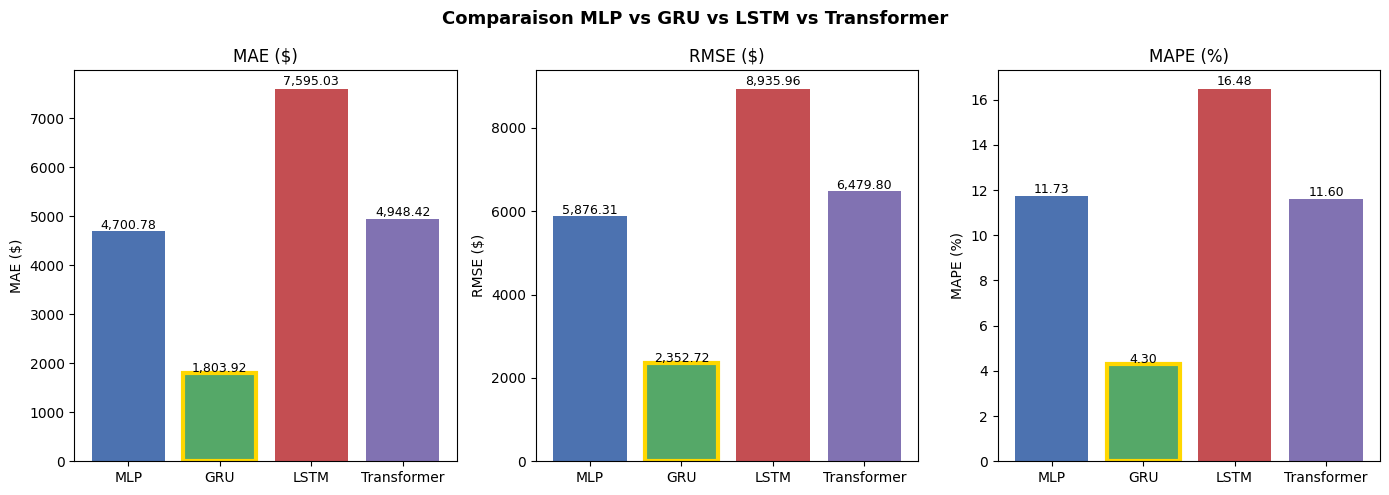

In [274]:
trans_results = pd.DataFrame({
    "Modèle":      ["MLP", "GRU", "LSTM", "Transformer"],
    "MAE ($)":     [mlp_mae,     gru_mae,     lstm_mae,     trans_mae],
    "RMSE ($)":    [mlp_rmse,    gru_rmse,    lstm_rmse,    trans_rmse],
    "MAPE (%)":    [mlp_mape,    gru_mape,    lstm_mape,    trans_mape],
    "Dir. Acc (%)": [mlp_dir_acc, gru_dir_acc, lstm_dir_acc, trans_dir_acc],
})

# Affichage texte
print(trans_results.to_string(index=False))
print(f"\n Champion : {champion_name}")

# Visualisation barres côte à côte
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

colors = ["#4C72B0", "#55A868", "#C44E52", "#8172B2"]

for ax, col in zip(axes, ["MAE ($)", "RMSE ($)", "MAPE (%)"]):
    ax.bar(trans_results["Modèle"], trans_results[col], color=colors)
    ax.set_title(col)
    ax.set_ylabel(col)
    for i, v in enumerate(trans_results[col]):
        ax.text(i, v * 1.01, f"{v:,.2f}", ha="center", fontsize=9)
    # Mettre en surbrillance le champion
    best_idx = trans_results["Modèle"].tolist().index(champion_name)
    axes[list(axes).index(ax)].patches[best_idx].set_edgecolor("gold")
    axes[list(axes).index(ax)].patches[best_idx].set_linewidth(3)

fig.suptitle("Comparaison MLP vs GRU vs LSTM vs Transformer", fontsize=13, fontweight="bold")
fig.tight_layout()
plt.show()


### Étape 7.3 — Comparaison finale : MLP vs GRU vs LSTM vs Transformer


In [275]:
print(f"MLP         : MAE = {mlp_mae:,.0f} $")
print(f"GRU         : MAE = {gru_mae:,.0f} $  <- champion !")
print(f"LSTM        : MAE = {lstm_mae:,.0f} $")
print(f"Transformer : MAE = {trans_mae:,.0f} $")

champion_name = "GRU"


MLP         : MAE = 4,701 $
GRU         : MAE = 1,804 $  <- champion !
LSTM        : MAE = 7,595 $
Transformer : MAE = 4,948 $


### Étape 7.4 — Sauvegarde du champion


In [276]:
import joblib

# Le GRU est le champion → on le sauvegarde directement
gru_model.save("bitcoin_gru_champion.keras")
joblib.dump(scaler, "bitcoin_scaler.pkl")

print("Modèle sauvegardé  : bitcoin_gru_champion.keras")
print("Scaler sauvegardé  : bitcoin_scaler.pkl")


Modèle sauvegardé  : bitcoin_gru_champion.keras
Scaler sauvegardé  : bitcoin_scaler.pkl


---
# Partie 8 — Mise à jour des données avec CoinGecko API

On récupère les données Bitcoin récentes (2022 → 2026) via l'API gratuite CoinGecko,
puis on les fusionne avec l'ancien CSV (2014 → 2022) pour re-entraîner le modèle.


In [279]:
import subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "install", "yfinance", "-q"], check=True)
import yfinance as yf

# --- Étape 1 : Charger l'ancien CSV ---
df_old = pd.read_csv("../BTC-Daily.csv")
df_old["Date"] = pd.to_datetime(df_old["date"])
df_old = df_old.sort_values("Date").reset_index(drop=True)
last_date = df_old["Date"].max()
print(f"Données existantes : {len(df_old)} lignes  ({df_old['Date'].min().date()} → {last_date.date()})")

# --- Étape 2 : Télécharger les données manquantes via yfinance ---
start = (last_date + pd.Timedelta(days=1)).strftime("%Y-%m-%d")
btc = yf.download("BTC-USD", start=start, interval="1d", progress=False, auto_adjust=True)
btc = btc.reset_index()

# Rename columns
btc.columns = [c[0] if isinstance(c, tuple) else c for c in btc.columns]
btc = btc.rename(columns={"Date": "Date", "Close": "close"})
btc["Date"] = pd.to_datetime(btc["Date"]).dt.normalize()

# Volume sur Yahoo Finance pour BTC-USD = Volume en BTC → Volume USD ≈ Volume * close
btc["Volume USD"] = btc["Volume"] * btc["close"]

df_new = btc[["Date", "close", "Volume USD"]].copy()
print(f"Nouvelles lignes Yahoo Finance : {len(df_new)}  ({df_new['Date'].min().date()} → {df_new['Date'].max().date()})")

# --- Étape 3 : Fusionner les deux datasets ---
df_combined = pd.concat([
    df_old[["Date", "close", "Volume USD"]],
    df_new
], ignore_index=True).sort_values("Date").drop_duplicates("Date").reset_index(drop=True)

print(f"\nDataset combiné : {len(df_combined)} lignes  ({df_combined['Date'].min().date()} → {df_combined['Date'].max().date()})")


Données existantes : 2651 lignes  (2014-11-28 → 2022-03-01)
Nouvelles lignes Yahoo Finance : 1552  (2022-03-02 → 2026-05-31)

Dataset combiné : 4203 lignes  (2014-11-28 → 2026-05-31)


In [280]:
# --- Préparer les données pour le re-entraînement ---
data_updated = df_combined[["close", "Volume USD"]]

scaler_new = MinMaxScaler()
scaled_new = scaler_new.fit_transform(data_updated)

# Fenêtres glissantes (même window = 30)
X_new, y_new = [], []
for i in range(window, len(scaled_new)):
    X_new.append(scaled_new[i - window:i, :])
    y_new.append(scaled_new[i, 0])

X_new = np.array(X_new)
y_new = np.array(y_new)

split_new = int(len(X_new) * 0.8)
X_train_new, X_test_new = X_new[:split_new], X_new[split_new:]
y_train_new, y_test_new = y_new[:split_new], y_new[split_new:]

print(f"Train : {X_train_new.shape}  |  Test : {X_test_new.shape}")

# --- Re-construire et re-entraîner le GRU ---
from tensorflow.keras.layers import GRU

gru_updated = Sequential()
gru_updated.add(GRU(50, return_sequences=True, input_shape=(30, 2)))
gru_updated.add(GRU(50))
gru_updated.add(Dense(1))

gru_updated.compile(optimizer="adam", loss="mse")

callbacks_new = [
    EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3),
]

gru_updated.fit(
    X_train_new, y_train_new,
    epochs=50, batch_size=32,
    validation_split=0.1,
    callbacks=callbacks_new,
    verbose=1
)

# --- Évaluation ---
preds_raw = gru_updated.predict(X_test_new)
dummy_up = np.zeros((len(preds_raw), 2))
dummy_up[:, 0] = preds_raw[:, 0]
preds_updated  = scaler_new.inverse_transform(dummy_up)[:, 0].reshape(-1, 1)

dummy_real_up = np.zeros((len(y_test_new), 2))
dummy_real_up[:, 0] = y_test_new
real_updated = scaler_new.inverse_transform(dummy_real_up)[:, 0].reshape(-1, 1)

mae_up   = mean_absolute_error(real_updated, preds_updated)
rmse_up  = np.sqrt(mean_squared_error(real_updated, preds_updated))
mape_up  = np.mean(np.abs((real_updated - preds_updated) / real_updated)) * 100

print(f"\nGRU Updated — MAE: {mae_up:,.0f} $ | RMSE: {rmse_up:,.0f} $ | MAPE: {mape_up:.1f}%")

# --- Sauvegarder le modèle mis à jour ---
gru_updated.save("bitcoin_gru_updated.keras")
joblib.dump(scaler_new, "bitcoin_scaler_updated.pkl")
print("\nModèle mis à jour sauvegardé : bitcoin_gru_updated.keras")
print("Scaler mis à jour sauvegardé : bitcoin_scaler_updated.pkl")


Train : (3338, 30, 2)  |  Test : (835, 30, 2)
Epoch 1/50


c:\Users\paulm\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


94/94 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - loss: 0.0015 - val_loss: 1.0469e-04 - learning_rate: 0.0010
Epoch 2/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 9.7828e-05 - val_loss: 7.7285e-05 - learning_rate: 0.0010
Epoch 3/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 9.6496e-05 - val_loss: 6.7912e-05 - learning_rate: 0.0010
Epoch 4/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 8.9038e-05 - val_loss: 6.0578e-05 - learning_rate: 0.0010
Epoch 5/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 7.1932e-05 - val_loss: 6.5414e-05 - learning_rate: 5.0000e-04
Epoch 6/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 7.3505e-05 - val_loss: 1.1822e-04 - learning_rate: 5.0000e-04
Epoch 7/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 6.8867e-05 - val_loss: 5.3680e-05 - learning_rate: 5.0000e-04
Epoch 8/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 6.3380e-05 - val_loss: 5.6905e-05 - learning_rate: 2.5000e-04
Epoch 9/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 6.32